In [1]:
import torch

In [2]:
#pip install --upgrade typing_extensions

In [3]:
print(torch.__version__)

2.4.1


In [4]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Using device : {device}")

Using device : cpu


In [5]:
import torch
import numpy as np

data = [[1,2],[3,4]]
print(type(data))
x_tensor = torch.tensor(data)

print(f"Pytorch Tensor :\n{x_tensor}\n")

np_array = np.array(data)
print(type(np_array))

X_np_tensor = torch.from_numpy(np_array)
print(type(X_np_tensor))

print(type(x_tensor.numpy()))

<class 'list'>
Pytorch Tensor :
tensor([[1, 2],
        [3, 4]])

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
<class 'numpy.ndarray'>


# Autograd: Automatic Differentiation
 
This is where the magic happens. PyTorch can automatically calculate gradients for any computation performed on tensors. It does this by building a computation graph and then using the chain rule to find the gradients.

When you create a tensor, you can tell PyTorch to track its computational history by setting requires_grad=True.

Let's see a simple example. Suppose we have a variable w and we define a function Q=3w3−w2. We want to find the gradient dwdQ at w=2.

In [6]:
w = torch.tensor(2.0, requires_grad = True)

Q = 3*w**3 - w**2
# here we are backpropagate to compute the gradients
Q.backward()

print(f"The gradient dQ/dw is : {w.grad}")

The gradient dQ/dw is : 32.0


# The nn.Module

In PyTorch, all neural network models are subclasses of torch.nn.Module. You define the layers of your network in the __init__ method and specify how data flows through them in the forward method.

In [7]:
import torch
from torch import nn 

class SimpleNet(nn.Module): # SimpleNet is child class (subClass) and here nn.Module is parent class
    def __init__(self):
        super(SimpleNet,self).__init__() #super() is used to call a method from the parent class. here it calls __init__() constructor of the parent
        self.layer1c= nn.Linear(in_features=10,out_features=20)
        self.activation=nn.ReLU()
        self.layer2=nn.Linear(in_features=20,out_features=5)
    def forward(self,x):
        x=self.layer1(x)
        x=self.activation(x)
        x=elf.layer2(x)
        return x
model = SimpleNet()
print(model)

SimpleNet(
  (layer1c): Linear(in_features=10, out_features=20, bias=True)
  (activation): ReLU()
  (layer2): Linear(in_features=20, out_features=5, bias=True)
)


In [8]:
import torch
from torch import nn 

class SimpleNet(nn.Module): # SimpleNet is child class (subClass) and here nn.Module is parent class
    def __init__(self):
        super().__init__() #super() is used to call a method from the parent class. here it calls __init__() constructor of the parent
        self.layers = nn.Sequential(
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.layers(x) # pass the input tensor through sequential container

model = SimpleNet()
print(model)

SimpleNet(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [9]:
import torch
from torch import nn 

class SimpleNet(nn.Module): 
    def __init__(self, input_size = 784, num_classes=10):
        super().__init__() 
        self.layers = nn.Sequential(
            # Hidden layer 1
            nn.Linear(input_size,128),
            nn.ReLU(),
            # Hidden layer 2
            nn.Linear(128,64),
            nn.ReLU(),
            # output layer
            nn.Linear(64,num_classes)
        )
    def forward(self,x):
        return self.layers(x) # pass the input tensor through sequential container

model = SimpleNet()
print(model)


dummy_input = torch.randn(1,784)

logits = model(dummy_input)

print(f"\n shape of the output:{logits.shape}")
print(f"\n output:{logits}")

SimpleNet(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

 shape of the output:torch.Size([1, 10])

 output:tensor([[-0.0441, -0.0836, -0.0125,  0.1256,  0.0488,  0.1013, -0.0836,  0.0309,
         -0.0050,  0.1319]], grad_fn=<AddmmBackward0>)


# Logistic (or sigmoid ) 

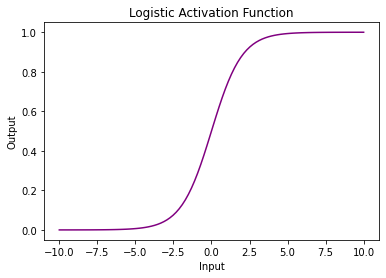

In [10]:
import torch
from torch import nn
import matplotlib.pyplot as plt

x = torch.linspace(-10,10,100)

y = torch.sigmoid(x)

plt.plot(x.numpy(),y.numpy(),color='purple')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title("Logistic Activation Function")
plt.show()

# ReLU

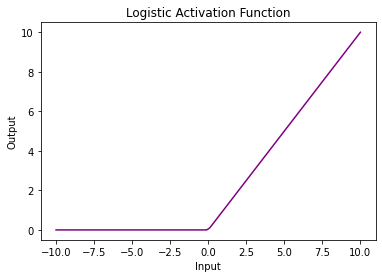

In [11]:
import torch
from torch import nn
import matplotlib.pyplot as plt

x = torch.linspace(-10,10,100)

y = torch.relu(x)

plt.plot(x.numpy(),y.numpy(),color='purple')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title("Logistic Activation Function")
plt.show()

# Loss Function and Optimizer 

***Loss Function (torch.nn)***: This measures how far your model's prediction is from the actual target. PyTorch has many common ones built-in, like **nn.MSELoss (for regression)** or **nn.CrossEntropyLoss (for classification)**.

***Optimizer (torch.optim)***: This implements an optimization algorithm (like SGD or Adam) to update your model's parameters (weights) based on the gradients computed by Autograd.


### A Simple Linear Regression Example:

In [12]:
w_true = 2
b_true = 1

X = torch.randn(100,1)*10
y = w_true*X+b_true+torch.randn(100,1)*2


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear = nn.Linear(in_features=1,out_features=1)
    def forward(self,x):
        return self.Linear(x)
    
model = LinearRegressionModel()
print(model)

##loss function
loss_fn = nn.MSELoss()

##optimizer
optimizer = torch.optim.SGD(model.parameters(),lr=0.001)

epochs = 100

for epoch in range(epochs):
    
    y_pred = model(X)
    
    loss = loss_fn(y_pred,y)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    if (epoch + 1)%10 ==0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss:{loss.item():.4f}")

[w_learned,b_learned] = model.parameters()
print(f"\nTrue w: {w_true}, Learned w: {w_learned.item():.3f}")
print(f"\nTrue b: {b_true}, Learned b: {b_learned.item():.3f}")

LinearRegressionModel(
  (Linear): Linear(in_features=1, out_features=1, bias=True)
)
Epoch [10/100], Loss:11.8152
Epoch [20/100], Loss:3.5797
Epoch [30/100], Loss:3.2983
Epoch [40/100], Loss:3.2810
Epoch [50/100], Loss:3.2727
Epoch [60/100], Loss:3.2651
Epoch [70/100], Loss:3.2577
Epoch [80/100], Loss:3.2507
Epoch [90/100], Loss:3.2439
Epoch [100/100], Loss:3.2374

True w: 2, Learned w: 2.032

True b: 1, Learned b: 0.502
